# 00 — The data layer

Everything downstream trades on prices, so it is worth getting them right first. This notebook covers
the three things the `statarb.data` module does: load adjusted daily prices, turn them into returns, and
align a multi-name panel onto a common calendar. I use the cached semiconductor panel throughout.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statarb import data, config

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
OI = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "grey": "#8A8F98"}

## Loading prices

`get_prices` reads from a cached CSV when one exists and only hits the network otherwise, so the whole
study runs offline once the data is cached. Prices are split- and dividend-adjusted closes.

In [2]:
px = data.align_prices(pd.read_csv("../data/semis.csv", index_col=0, parse_dates=True))
print(f"{px.shape[1]} names, {px.shape[0]} trading days, {px.index.min().date()} to {px.index.max().date()}")
px.iloc[:, :6].tail(3).round(2)

21 names, 3019 trading days, 2013-01-02 to 2024-12-30


,ADI,AMAT,AMD,ASML,AVGO,INTC
Date,,,,,,
2024-12-26,213.27,165.48,125.06,705.69,242.27,20.44
2024-12-27,212.22,164.77,125.19,703.46,238.71,20.30
2024-12-30,207.89,161.62,122.44,686.26,232.61,19.82


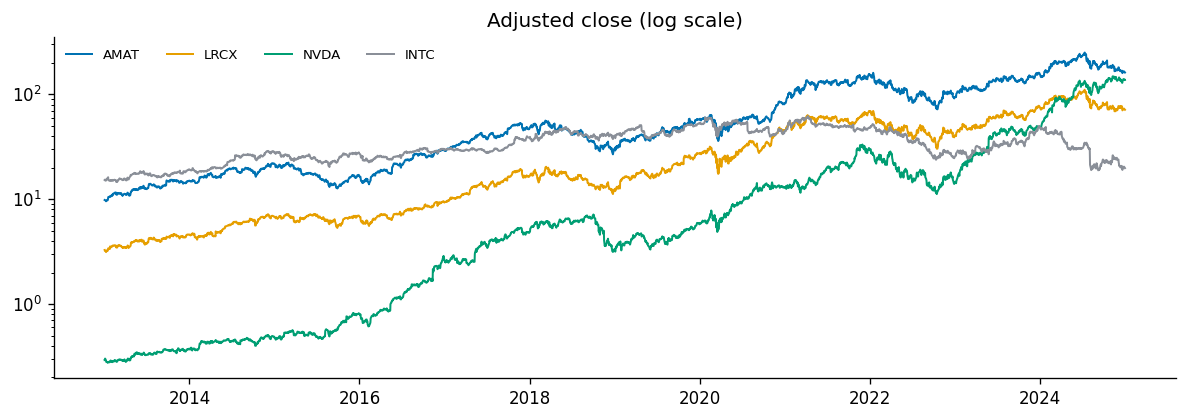

In [3]:
# A few names on a log axis — semis move together, which is exactly why pairs trading is tempting here.
fig, ax = plt.subplots(figsize=(10, 3.6))
for t, c in zip(["AMAT", "LRCX", "NVDA", "INTC"], OI.values()):
    ax.plot(px.index, px[t], label=t, color=c, lw=1.2)
ax.set_yscale("log"); ax.legend(frameon=False, ncol=4, fontsize=8)
ax.set_title("Adjusted close (log scale)"); plt.tight_layout(); plt.show()

## Returns

I work in **log returns**, $r_t = \ln(p_t / p_{t-1})$, because they add across time and behave better in the
models later on. Simple returns $p_t/p_{t-1}-1$ are available too. Either way the first row is dropped
since there is no prior price to difference against.

In [4]:
rets = data.to_returns(px, kind="log")
ann = pd.DataFrame({"ann. vol": rets.std() * np.sqrt(252),
                    "ann. mean": rets.mean() * 252}).sort_values("ann. vol").round(3)
print("Annualized, a few names:")
print(ann.head(6))

Annualized, a few names:
      ann. vol  ann. mean
TXN      0.270      0.174
SMH      0.288      0.235
SOXX     0.293      0.219
ADI      0.298      0.154
TSM      0.306      0.228
INTC     0.341      0.022


## Aligning a panel

Different tickers can have missing days (holidays, halts, late listings). `align_prices` keeps only the
dates where **every** name has a price, so a cross-sectional row is always complete. With cointegration
work this matters: a pair must be compared on the same calendar, or the spread is meaningless.

In [5]:
raw = pd.read_csv("../data/semis.csv", index_col=0, parse_dates=True)
aligned = data.align_prices(raw)
print(f"rows before alignment: {len(raw)}   after: {len(aligned)}   dropped: {len(raw) - len(aligned)}")

rows before alignment: 3019   after: 3019   dropped: 0


That is the whole data layer: adjusted prices in, clean returns and an aligned panel out. Next I use
these to ask whether any pair is actually cointegrated.